In [21]:
# ===============================================================
# Imports
# ===============================================================
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns



In [22]:
# ===============================================================
# Load Data
# ===============================================================
data = pd.read_csv("data.csv")

In [23]:
# ===============================================================
# Select Columns for Clustering
# ===============================================================
features = data[
    ["Episodes", "Duration_Minutes", "Score", "Popularity", "Members"]
].copy()

In [24]:
# ===============================================================
# Data Cleaning
# ===============================================================
for col in features.columns:
    features[col] = pd.to_numeric(features[col], errors="coerce")

features = features.dropna()

In [25]:
# ===============================================================
# Data Normalization
# ===============================================================
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [26]:
# ===============================================================
# Select Optimal Number of Clusters using Elbow Method
# ===============================================================
wcss = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

Tabla K vs WCSS:


,k,WCSS
0,1,72355.000000
1,2,52618.199118
2,3,43455.577416
3,4,34970.936561
4,5,25421.046181
5,6,21977.930628
6,7,19779.285607
7,8,18075.599745
8,9,16759.897619


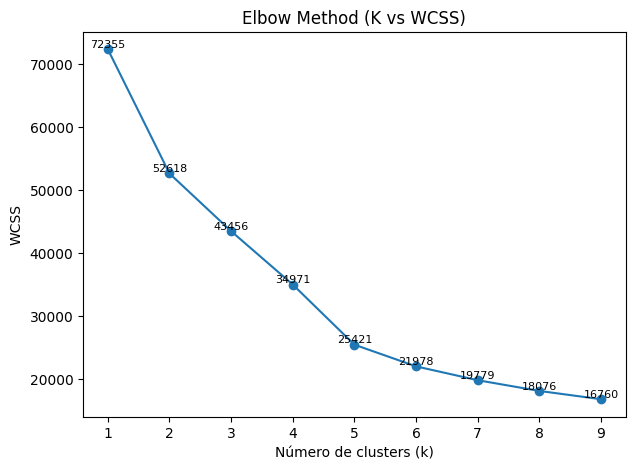

In [27]:
# ---------------------------------------------------------------
# Show table K vs WCSS
# ---------------------------------------------------------------
elbow_df = pd.DataFrame({"k": k_values, "WCSS": wcss})

print("Tabla K vs WCSS:")
display(elbow_df)

# ---------------------------------------------------------------
# Plot Elbow with points and values
# ---------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(k_values, wcss, marker="o", linestyle="-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method (K vs WCSS)")
plt.xticks(k_values)

for x, y in zip(k_values, wcss):
    plt.text(x, y, f"{y:.0f}", ha="center", va="bottom", fontsize=8)

plt.show()

Cluster sizes:
cluster
0    6323
1    6436
2     356
3    1347
4       9
Name: count, dtype: int64

Centroids (original scale):


,Episodes,Duration_Minutes,Score,Popularity,Members
0,14.054344,21.657188,6.965992,4292.625750,6.250687e+04
1,8.266335,16.308027,5.689947,11578.708307,2.089162e+03
2,25.691011,28.556180,7.912798,180.904494,1.009842e+06
3,1.040801,91.510386,6.958834,6249.913947,4.510363e+04
4,1634.666667,8.555556,5.948778,11603.222222,6.849222e+03


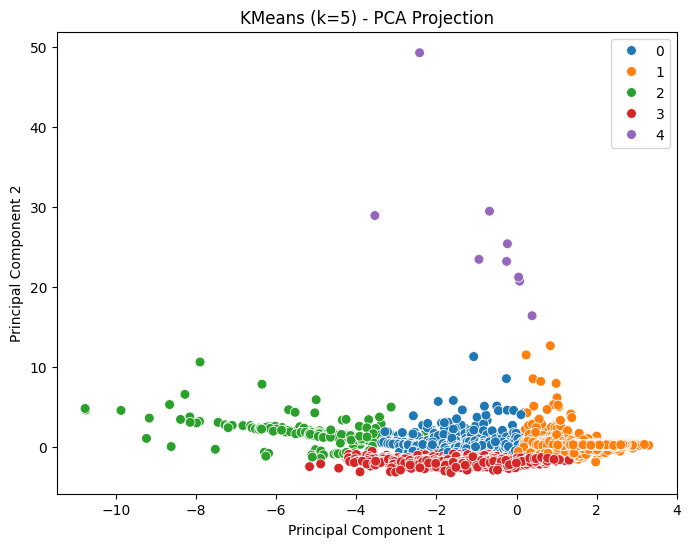

In [28]:
# ===============================================================
# Set selected k value and assign clusters
# ===============================================================
chosen_k = 5

# Create and fit the model
kmeans = KMeans(n_clusters=chosen_k, random_state=42)
kmeans.fit(scaled_features)

# Save labels in the cleaned dataframe
labels = kmeans.labels_
features["cluster"] = labels

# Also add cluster to the original dataframe
data.loc[features.index, "cluster"] = labels

# ===============================================================
# View cluster sizes
# ===============================================================
print("Cluster sizes:")
print(features["cluster"].value_counts().sort_index())

# ===============================================================
# Get centroids in original scale
# ===============================================================
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(
    centroids,
    columns=features.columns[:-1],  # original columns without 'cluster'
)
print("\nCentroids (original scale):")
display(centroids_df)

# ===============================================================
# 2D Visualization with PCA
# ===============================================================
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=proj[:, 0], y=proj[:, 1], hue=labels, palette="tab10", s=50, legend="full"
)
plt.title(f"KMeans (k={chosen_k}) - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Centroids (averages by cluster):


,Episodes,Duration_Minutes,Score,Popularity,Members
cluster,,,,,
0,14.060573,21.665823,6.966879,4288.479519,6.256977e+04
1,8.265382,16.311684,5.690672,11573.717526,2.095931e+03
2,25.691011,28.556180,7.912798,180.904494,1.009842e+06
3,1.040831,91.536006,6.958780,6251.403118,4.512193e+04
4,1634.666667,8.555556,5.948778,11603.222222,6.849222e+03



Number of animes per cluster:


cluster
1    6436
0    6323
3    1347
2     356
4       9
Name: count, dtype: int64

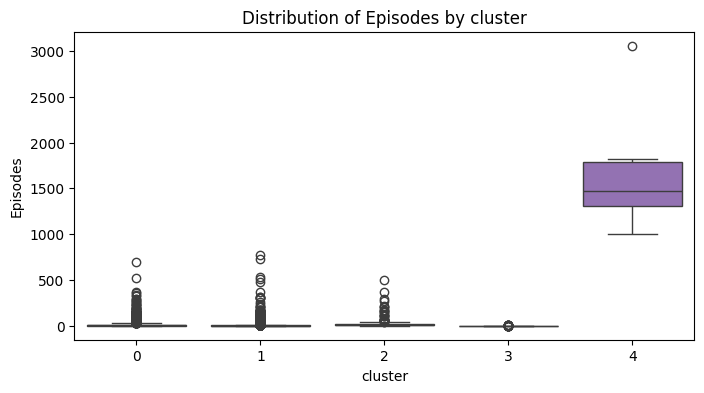

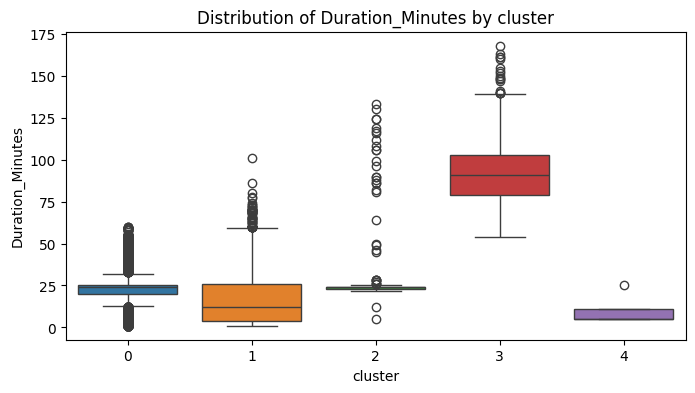

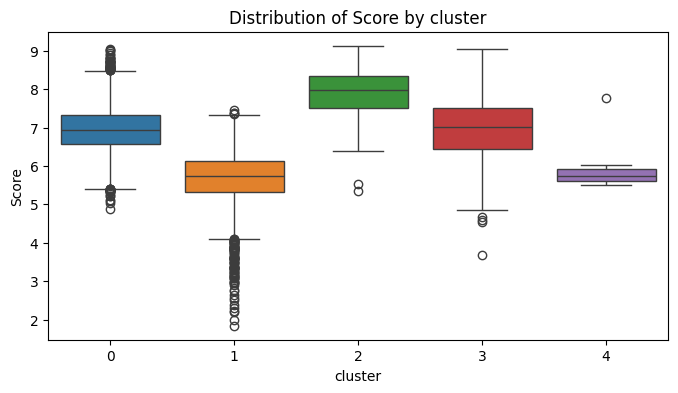

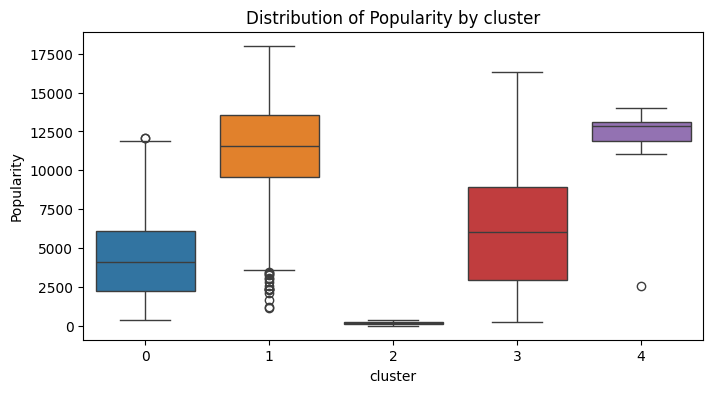

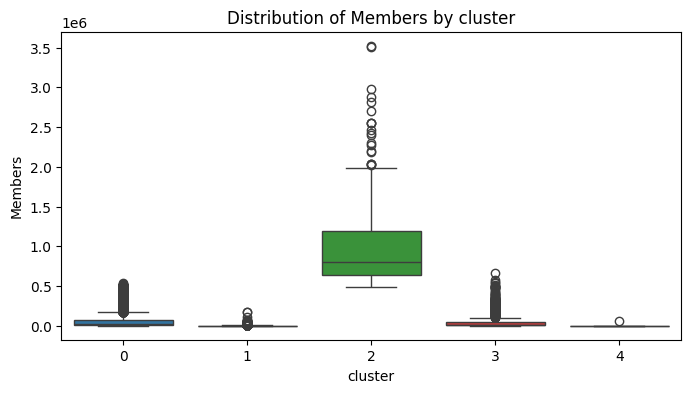


--- Representative Examples by Cluster ---

Cluster 0: Standard Season Anime (Average TV/OVAs)
  - Key characteristics: {'Episodes': 14.060572513047603, 'Duration_Minutes': 21.6658231851969, 'Score': 6.966878538668354, 'Popularity': 4288.4795192155625, 'Members': 62569.769413253205, 'cluster': 0.0}
  - Examples: ['X OVA', 'Future Card Buddyfight Triple D', 'Senryuu Shoujo', 'Oide yo! Mizuryuu Kei Land', 'Project Scard: Praeter no Kizu']

Cluster 1: Niche / Low Popularity Anime (Obscure Works)
  - Key characteristics: {'Episodes': 8.265382224984462, 'Duration_Minutes': 16.311684275947794, 'Score': 5.6906721566190175, 'Popularity': 11573.717526413922, 'Members': 2095.9308576755748, 'cluster': 1.0}
  - Examples: ['Futari Zamurai Homare no Kawakiri', 'Dreams', 'Daraku Reijou The Animation: Hakoiri Ojousama Netorare Choukyou Kiroku', 'Paul no Miracle Daisakusen', 'Robot Atom']

Cluster 2: Mainstream Hits / The 'Big Names' (High Community)
  - Key characteristics: {'Episodes': 25.6910112359

In [29]:
# ===============================================================
# Post K-Means Analysis
# ===============================================================

# 1) Centroids by cluster
print("Centroids (averages by cluster):")
centroids = features.groupby("cluster")[
    ["Episodes", "Duration_Minutes", "Score", "Popularity", "Members"]
].mean()
display(centroids)

# 2) Cluster sizes
print("\nNumber of animes per cluster:")
display(features["cluster"].value_counts())

# 3) Distribution of variables by cluster
variables = ["Episodes", "Duration_Minutes", "Score", "Popularity", "Members"]

for var in variables:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        x="cluster",
        y=var,
        data=features,
        hue="cluster",
        dodge=False,
        palette="tab10",
        legend=False,
    )
    plt.title(f"Distribution of {var} by cluster")
    plt.show()

# ===============================================================
# Cluster Interpretation (Anime Context)
# ===============================================================
print("\n--- Representative Examples by Cluster ---")

# Interpretation dictionary based on your plots
cluster_names = {
    0: "Standard Season Anime (Average TV/OVAs)",
    1: "Niche / Low Popularity Anime (Obscure Works)",
    2: "Mainstream Hits / The 'Big Names' (High Community)",
    3: "Anime Movies (Feature Films)",
    4: "Short-Format Series / Kodomo (Many short episodes)",
}

for c in sorted(features["cluster"].unique()):
    # Select 5 random examples from each cluster for verification
    sample_titles = (
        data.loc[features[features["cluster"] == c].index, "Title"]
        .sample(5, random_state=42)
        .values
    )

    print(f"\nCluster {c}: {cluster_names.get(c, 'Unknown')}")
    print(
        f"  - Key characteristics: {features[features['cluster'] == c].mean().to_dict()}"
    )
    print(f"  - Examples: {list(sample_titles)}")
